# 02 - Decision-Driven EDA

This notebook is focused on achieving the following:
- defining missing/unknown strategy
- validating encoding direction
- producing measurable evaluation plan (AUC, F1, confusion matrix, CV)

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

BASE_DIR = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

candidates = [
    BASE_DIR / "data" / "bank-full.csv",
    BASE_DIR / "data" / "bank.csv",
]

DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Dataset not found. Tried:\n" + "\n".join(str(p) for p in candidates)
    )

print("Using dataset:", DATA_PATH)

FEATURES = ["age", "job", "default", "housing", "loan", "marital", "education"]
TARGET = "y"
CAT_FEATURES = ["job", "default", "housing", "loan", "marital", "education"]


Using dataset: /home/ian-migwi/Documents/Projects/term_deposit_predictor/data/bank-full.csv


In [8]:
df = pd.read_csv(DATA_PATH, sep=';')
df = df[FEATURES + [TARGET]].copy()

print('Shape:', df.shape)
display(df.head())

Shape: (45211, 8)


,age,job,default,housing,loan,marital,education,y
0,58,management,no,yes,no,married,tertiary,no
1,44,technician,no,yes,no,single,secondary,no
2,33,entrepreneur,no,yes,yes,married,secondary,no
3,47,blue-collar,no,yes,no,married,unknown,no
4,33,unknown,no,no,no,single,unknown,no


## 1) Target Health

,count,pct
class,,
no,39922,0.883015
yes,5289,0.116985


Majority-class baseline accuracy: 0.883


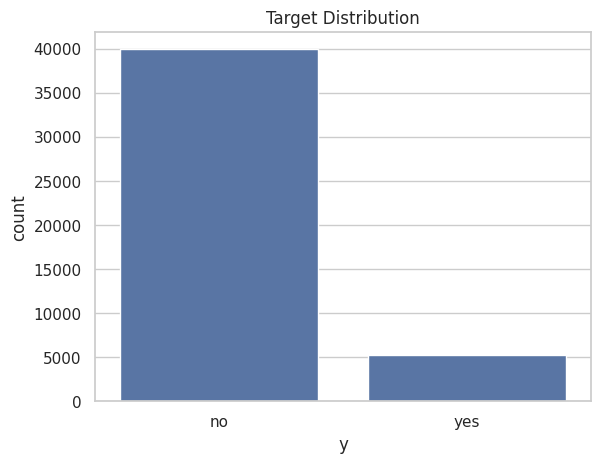

In [9]:
target_dist = df[TARGET].value_counts(dropna=False).rename_axis('class').to_frame('count')
target_dist['pct'] = target_dist['count'] / target_dist['count'].sum()
display(target_dist)

baseline_majority = target_dist['pct'].max()
print('Majority-class baseline accuracy:', round(baseline_majority, 4))

ax = sns.countplot(data=df, x=TARGET)
ax.set_title('Target Distribution')
plt.show()

## 2) Data Quality and Unknown Audit

In [10]:
quality = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'null_count': df.isna().sum(),
    'null_pct': df.isna().mean()
})
display(quality)

unknown_rows = []
for col in CAT_FEATURES:
    count_unknown = (df[col] == 'unknown').sum()
    unknown_rows.append({'feature': col, 'unknown_count': count_unknown, 'unknown_pct': count_unknown / len(df)})

unknown_df = pd.DataFrame(unknown_rows).sort_values('unknown_pct', ascending=False)
display(unknown_df)

duplicate_count = df.duplicated().sum()
print('Duplicate rows:', duplicate_count)

,dtype,null_count,null_pct
age,int64,0,0.0
job,object,0,0.0
default,object,0,0.0
housing,object,0,0.0
loan,object,0,0.0
marital,object,0,0.0
education,object,0,0.0
y,object,0,0.0


,feature,unknown_count,unknown_pct
5,education,1857,0.041074
0,job,288,0.006370
1,default,0,0.000000
2,housing,0,0.000000
3,loan,0,0.000000
4,marital,0,0.000000


Duplicate rows: 34956


## 3) Category Frequency and Response Rate

In [11]:
def category_profile(data, feature, target='y', positive_label='yes'):
    g = data.groupby(feature, dropna=False)[target].agg(['count'])
    g['pct'] = g['count'] / len(data)
    g['response_rate'] = data.groupby(feature, dropna=False)[target].apply(lambda s: (s == positive_label).mean())
    return g.sort_values('count', ascending=False)

for col in CAT_FEATURES:
    print(f'\n=== {col} ===')
    display(category_profile(df, col, target=TARGET))


=== job ===


,count,pct,response_rate
job,,,
blue-collar,9732,0.215257,0.072750
management,9458,0.209197,0.137556
technician,7597,0.168034,0.110570
admin.,5171,0.114375,0.122027
services,4154,0.091880,0.088830
retired,2264,0.050076,0.227915
self-employed,1579,0.034925,0.118429
entrepreneur,1487,0.032890,0.082717
unemployed,1303,0.028820,0.155027



=== default ===


,count,pct,response_rate
default,,,
no,44396,0.981973,0.117961
yes,815,0.018027,0.063804



=== housing ===


...

,count,pct,response_rate
loan,,,
no,37967,0.839774,0.126557
yes,7244,0.160226,0.066814



=== marital ===


,count,pct,response_rate
marital,,,
married,27214,0.601933,0.101235
single,12790,0.282896,0.149492
divorced,5207,0.115171,0.119455



=== education ===


,count,pct,response_rate
education,,,
secondary,23202,0.513194,0.105594
tertiary,13301,0.294198,0.150064
primary,6851,0.151534,0.086265
unknown,1857,0.041074,0.135703


## 4) Age Signal Check

count    45211.000000
mean        40.936210
std         10.618762
min         18.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64

/tmp/ipykernel_57883/2347071366.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_profile = df.assign(age_bin=age_bins).groupby('age_bin')[TARGET].agg(count='count', response_rate=lambda s: (s == 'yes').mean())


,count,response_rate
age_bin,,
"(16.999, 24.0]",809,0.255871
"(24.0, 34.0]",14204,0.124824
"(34.0, 44.0]",14534,0.096601
"(44.0, 54.0]",9958,0.092689
"(54.0, 64.0]",4896,0.130923
"(64.0, 100.0]",810,0.420988


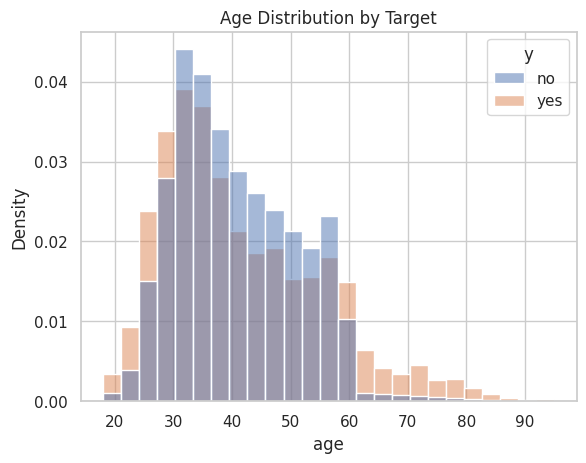

In [12]:
display(df['age'].describe())

age_bins = pd.cut(df['age'], bins=[17, 24, 34, 44, 54, 64, 100], include_lowest=True)
age_profile = df.assign(age_bin=age_bins).groupby('age_bin')[TARGET].agg(count='count', response_rate=lambda s: (s == 'yes').mean())
display(age_profile)

ax = sns.histplot(data=df, x='age', hue=TARGET, bins=25, stat='density', common_norm=False)
ax.set_title('Age Distribution by Target')
plt.show()

## 5) Split Diagnostics (Unseen Category Risk)

In [13]:
X = df[FEATURES]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Target rate (train):', round((y_train == 'yes').mean(), 4))
print('Target rate (test) :', round((y_test == 'yes').mean(), 4))

coverage_rows = []
for col in CAT_FEATURES:
    train_cats = set(X_train[col].unique())
    test_cats = set(X_test[col].unique())
    unseen_in_test = sorted(list(test_cats - train_cats))
    coverage_rows.append({
        'feature': col,
        'train_unique': len(train_cats),
        'test_unique': len(test_cats),
        'unseen_in_test_count': len(unseen_in_test),
        'unseen_in_test_values': ', '.join(unseen_in_test) if unseen_in_test else ''
    })

coverage_df = pd.DataFrame(coverage_rows)
display(coverage_df)

Target rate (train): 0.117
Target rate (test) : 0.117


,feature,train_unique,test_unique,unseen_in_test_count,unseen_in_test_values
0,job,12,12,0,
1,default,2,2,0,
2,housing,2,2,0,
3,loan,2,2,0,
4,marital,3,3,0,
5,education,4,4,0,


## 6) Decision Table (Output for `train.py` Changes)

In [14]:
decision_table = pd.DataFrame({
    'feature': FEATURES,
    'missing_strategy': ['none'] + ['keep_as_category_or_impute'] * 6,
    'unknown_strategy': ['n/a'] + ['to_confirm_from_unknown_rate'] * 6,
    'encoding': ['numeric_passthrough'] + ['one_hot'] * 6,
    'notes': ['confirm age scaling necessity'] + ['confirm rare-category threshold'] * 6
})
display(decision_table)

out_dir = BASE_DIR / 'notebooks' / 'artifacts'
out_dir.mkdir(parents=True, exist_ok=True)
decision_table.to_csv(out_dir / '02_eda_decisions.csv', index=False)
unknown_df.to_csv(out_dir / '02_eda_unknown_rates.csv', index=False)
coverage_df.to_csv(out_dir / '02_eda_split_coverage.csv', index=False)
print('Saved artifacts to', out_dir)

,feature,missing_strategy,unknown_strategy,encoding,notes
0,age,none,n/a,numeric_passthrough,confirm age scaling necessity
1,job,keep_as_category_or_impute,to_confirm_from_unknown_rate,one_hot,confirm rare-category threshold
2,default,keep_as_category_or_impute,to_confirm_from_unknown_rate,one_hot,confirm rare-category threshold
3,housing,keep_as_category_or_impute,to_confirm_from_unknown_rate,one_hot,confirm rare-category threshold
4,loan,keep_as_category_or_impute,to_confirm_from_unknown_rate,one_hot,confirm rare-category threshold
5,marital,keep_as_category_or_impute,to_confirm_from_unknown_rate,one_hot,confirm rare-category threshold
6,education,keep_as_category_or_impute,to_confirm_from_unknown_rate,one_hot,confirm rare-category threshold


Saved artifacts to /home/ian-migwi/Documents/Projects/term_deposit_predictor/notebooks/artifacts


## 7) Stage 1 Implementation Notes

After running this notebook, update `train.py` with:
1. Chosen missing/unknown handling policy
2. Improved categorical encoding path
3. Metrics: Accuracy, F1, confusion matrix, AUC-ROC
4. Stratified cross-validation with a small hyperparameter grid